# 1 - Carga y Configuracion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('data/dataset_f1_unido.csv', low_memory=False)

# 2 - Info del Dataset

In [4]:
print("\nValores nulos por columna:\n", df.isna().sum()[df.isna().sum() > 0])
print(df.info())


Valores nulos por columna:
 quali_position                 16265
driver_season_points             469
driver_season_position           469
driver_season_wins               469
constructor_season_points       1867
constructor_season_position     1867
constructor_season_wins         1867
constructor_race_points         1611
sprint_points                  26399
sprint_grid                    26399
sprint_position                26399
sprint_laps                    26399
total_pit_stops                21184
avg_pit_duration_ms            21184
fastest_lap_ms                 15718
avg_lap_ms                     15718
std_lap_ms                     15833
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   resultId                     26759 non-null  int64  
 1   raceId                       26759 non-nu

# 3 - Correlaciones y PairPlot

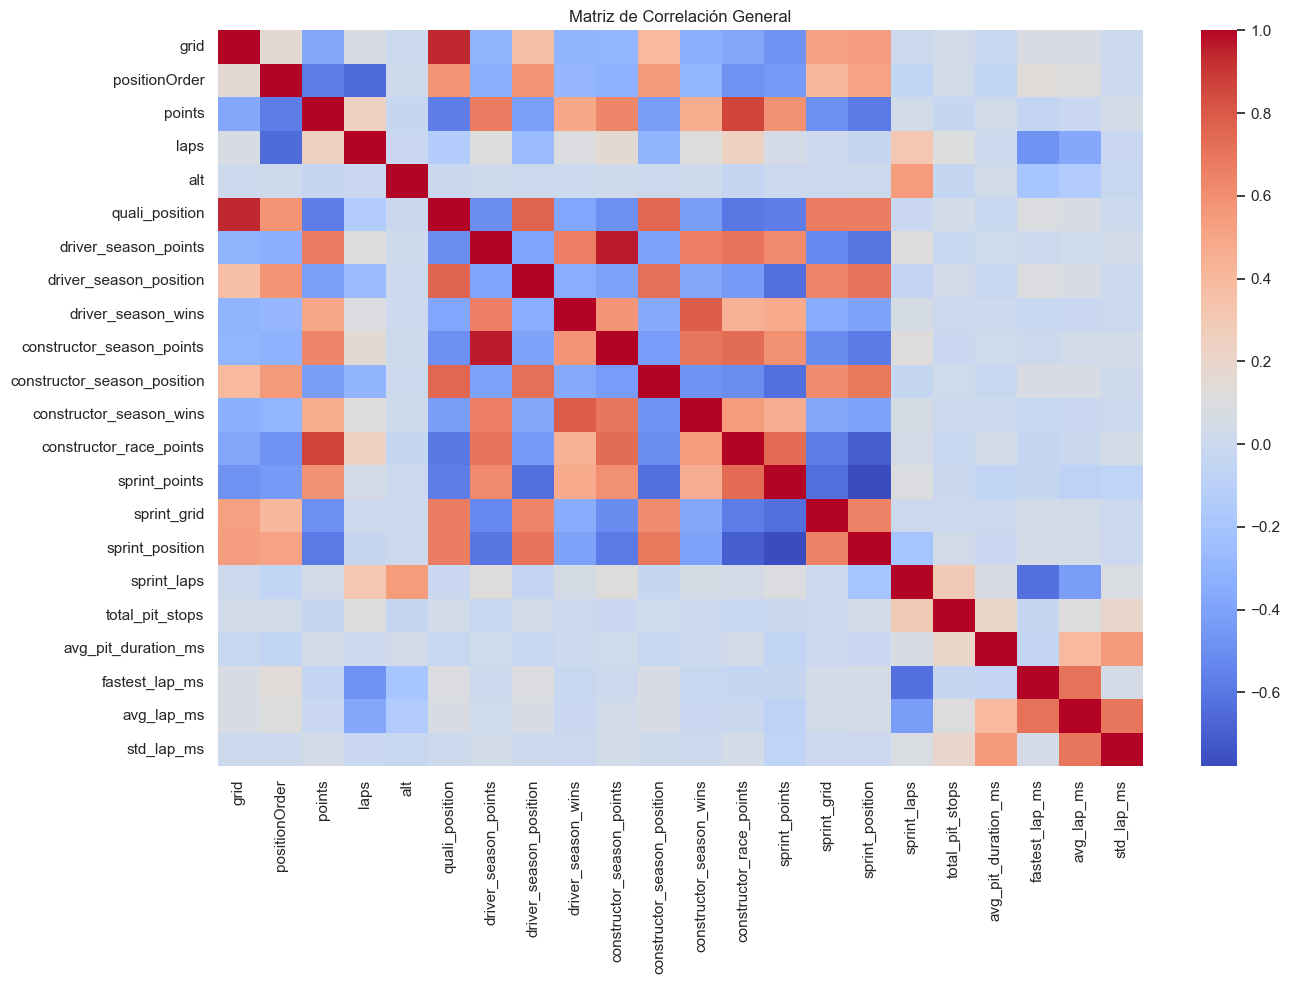


Generando Pairplot solo para el Top 5 asociado a 'points': ['points', 'constructor_race_points', 'driver_season_points', 'constructor_season_points', 'sprint_points']


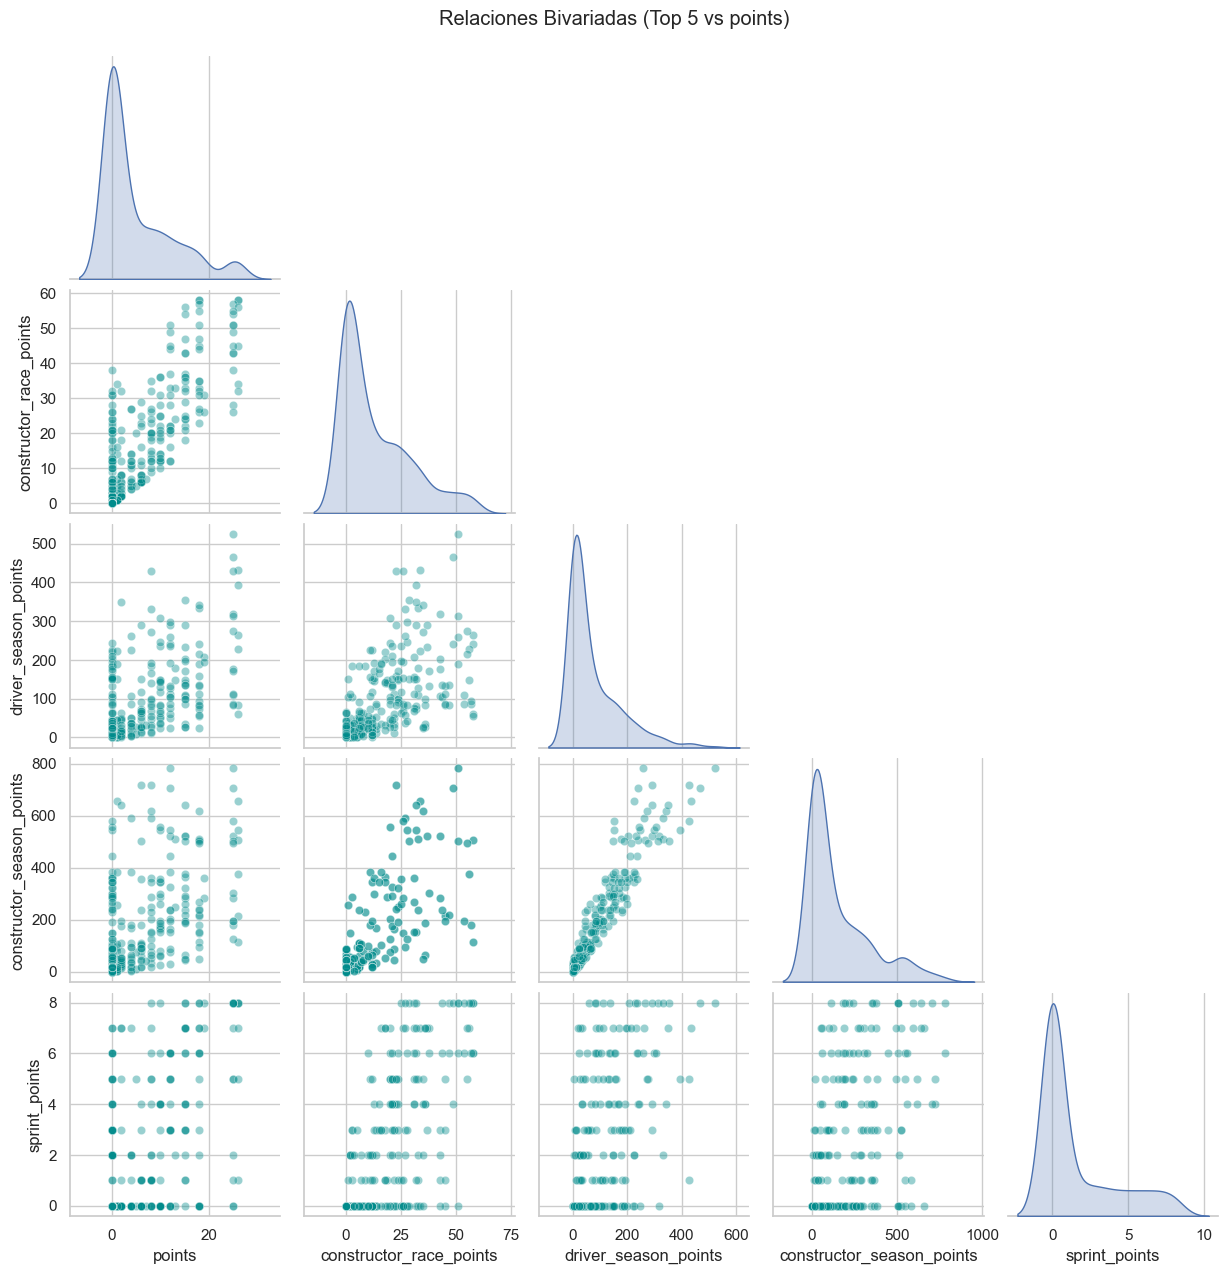

In [3]:
# 1. Filtrar numéricas y limpiar IDs basura
df_numeric = df.select_dtypes(include=['number'])
columnas_basura = ['resultId', 'raceId', 'driverId', 'constructorId', 'statusId', 'year', 'round']
df_numeric = df_numeric.drop(columns=[col for col in columnas_basura if col in df_numeric.columns])

if not df_numeric.empty:
    # 2. Matriz de Correlación General (Heatmap)
    plt.figure(figsize=(14, 10))
    matriz_corr = df_numeric.corr()
    # Mantenemos annot=False porque con tantas variables los números se enciman
    sns.heatmap(matriz_corr, annot=False, cmap="coolwarm")
    plt.title("Matriz de Correlación General")
    plt.tight_layout()
    plt.show()

    # 3. Pairplot Inteligente (Top 5 correlacionadas con la variable objetivo)
    variable_objetivo = 'points' 
    
    if variable_objetivo in matriz_corr.columns:
        # Extraer las 5 variables con mayor correlación (absoluta) con la variable objetivo
        top_variables = matriz_corr[variable_objetivo].abs().sort_values(ascending=False).head(5).index.tolist()
        print(f"\nGenerando Pairplot solo para el Top 5 asociado a '{variable_objetivo}': {top_variables}")
        
        df_pair = df_numeric[top_variables].dropna()
        
        if len(df_pair) > 5000:
            df_pair = df_pair.sample(n=5000, random_state=42)
            
        g = sns.pairplot(df_pair, diag_kind='kde', corner=True, plot_kws={'alpha': 0.4, 'color': 'darkcyan'})
        g.fig.suptitle(f'Relaciones Bivariadas (Top 5 vs {variable_objetivo})', y=1.02)
        plt.show()
    else:
        print(f"La variable {variable_objetivo} no se encontró para hacer el Pairplot.")
else:
    print("No se encontraron columnas numéricas para graficar.")